# Elliott Wave — a quantitative teardown 🔬
### A mechanical ZigZag+Fibonacci proxy for an irreducibly subjective method · the wave-3 entry · forward 5/10/20/40-day returns · one-sample & HAC *t* + a same-bars coin placebo · Fibonacci-band & threshold robustness · the completed-impulse correction test · a planted-edge faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Five_waves_predict%3F: Not_Supported](https://img.shields.io/badge/Five_waves_predict%3F-Not_Supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Elliott Wave has no single falsifiable rule — the count is hindsight-dependent — so we steelman it with the tightest mechanical version proponents accept and test only its **forward-looking** predictions. The honest finding: nothing clears **t = 2**, a same-bars coin ties it, and the result is robust to every knob — while a planted-edge control proves the harness *can* detect a real wave-3.

> ⚠️ **Data note.** yfinance auto-adjusted (total-return) daily OHLC; 8-tape index/ETF basket (SPY, QQQ, DIA, IWM, ^GSPC, ^IXIC, ^DJI, GLD); **as-of 2025-12-31** (no partial year). Price indices → no cross-sectional survivorship sort. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from elliott_wave import data, strategy as st

END = "2025-12-31"
TICKERS = list(data.TICKERS)
HAVE_REAL = data.have_real("SPY")

def pooled(fn, pct=0.05, **kw):
    """Pool one signal's forward returns + dirs across the cached basket, trimmed to END."""
    rets = {h: [] for h in st.HORIZONS}; dirs = {h: [] for h in st.HORIZONS}; npv = nen = 0
    for tk in TICKERS:
        if not data.have_real(tk):
            continue
        b = data.load_real(tk); b = b[b.index <= END]
        piv = st.zigzag(b["close"].to_numpy(float), pct=pct); ent = fn(piv, **kw)
        npv += len(piv); nen += len(ent)
        for h in st.HORIZONS:
            led = st.run_trades(b, ent, h, cost_bps=0.0)
            rets[h].append(led["ret_gross"].to_numpy()); dirs[h].append(led["dir"].to_numpy())
    return rets, dirs, npv, nen

print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2025-12-31', 'spy_start': '1993-01-29', 'spy_years': 32.9, 'spy_fp': '7ce3202106f8', 'n_pivots': 2512, 'n_entries': 661, 'w3': [(5, 661, -17, -19, 52, -1.02, -1.09, 0.843), (10, 661, 5, 3, 54, 0.22, 0.26, 0.415), (20, 661, 17, 15, 54, 0.53, 0.63, 0.301), (40, 660, 59, 57, 54, 1.32, 1.63, 0.093)], 'n_impulse': 1339, 'imp': [(5, 1339, 6, 48, 0.5, 0.46), (10, 1339, 15, 48, 0.96, 0.83), (20, 1335, 8, 46, 0.35, 0.26), (40, 1331, -41, 45, -1.42, -1.03)], 'fib': [('textbook 50-61.8%', 188, 60, 1.1), ('wide 38.2-78.6%', 661, 17, 0.53), ('deep 61.8-100%', 579, -23, -0.69)], 'zz': [(3, 1360, -10, -0.53), (5, 661, 17, 0.53), (8, 282, 50, 1.03)], 'spy': [(5, 67, -10, 54, -0.18, 0.571), (10, 67, 3, 58, 0.04, 0.486), (20, 67, 41, 57, 0.42, 0.345), (40, 67, 15, 54, 0.12, 0.464)], 'syn': [(0.0, 83, -35, 48, -0.97, -0.92, 0.81), (0.15, 112, 470, 78, 7.02, 7.33, 0.0)]}


real cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pooled wave-3 long-short over **661** entries: the largest statistic anywhere is **HAC t = 1.63 at 40d** (just beta); shorter horizons are noise/negative; same-bars coin **p = 0.30** at 20d. |
| **Tradability** | `MIRAGE` | No edge to charge costs against; the only positive number (40d, +59 bps) is indistinguishable from buy-and-hold. |
| **Five waves predict?** | `NOT SUPPORTED` | Neither the wave-3 extension nor the completed-impulse correction (40d **t = -1.42**) is distinguishable from chance. Synthetic control with a planted wave-3: **t = 7.02** — true negative, not a broken pipe. |

> 💡 In plain words: a mechanical Elliott rule predicts nothing out-of-sample, and the method's own irreducible subjectivity means a human count has even more freedom to fit the past. The engine isn't blind — there's just nothing there.

## 1 · The claim, steelmanned

Let a 5% percentage ZigZag produce alternating pivots $P_0, P_1, P_2, \dots$ A candidate **impulse 1-2** is a triple $(P_0, P_1, P_2)$ with wave 1 $= P_1-P_0$, wave 2 $= P_2-P_1$ of opposite sign, retracement $\rho = |P_2-P_1|/|P_1-P_0| \in [0.382, 0.786]$ (the Fibonacci band; textbook $0.5$–$0.618$ inside) and $P_2$ not breaching $P_0$ (Elliott's rule 2). The theory's tradable claim:

- **H₁ (wave 3 extends).** Entering with $\operatorname{sign}(P_1-P_0)$ one day after $P_2$ is confirmed earns a positive forward return.
- **H₂ (correction after five).** After a five-pivot impulse, a position *against* the impulse earns a positive forward return.

We test $\mathbb{E}[r] > 0$ with a one-sample and HAC *t*, against a **same-bars random-direction** null. **H₁ rejected** (max HAC t = 1.63, beaten by a coin). **H₂ rejected** (insignificant, wrong sign at 40d). The mechanical core predicts nothing — and the *un*-mechanical, hand-counted version has strictly more hindsight freedom, so it cannot be in a better position.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample / HAC *t* of the directional per-trade return vs 0:

$$t = \frac{\bar r}{\hat\sigma_{\mathrm{HAC}}/\sqrt{n}}, \qquad r_i = d_i\,\Big(\tfrac{P_{\text{exit}}}{P_{\text{entry}}}-1\Big),\; d_i=\operatorname{sign}(\text{wave 1}).$$

Two honesty problems. **(a) Beta contamination:** wave 1 is usually *up* on equity indices, so a long held 40 days is mostly market drift, not an Elliott edge — which is exactly why the only positive number appears at the longest horizon. **(b) Researcher freedom:** the Fibonacci band and the ZigZag threshold are free parameters; a positive at *one* setting is data-snooping. We answer (a) by reading short horizons and the coin placebo, and (b) by sweeping both knobs.

## 3 · How we'd know — the protocol

- **Universe.** 8 broad index/ETF tapes (yfinance daily, auto-adjusted); pooled for power. SPY spans 1993-01-29→2025-12-31 (33y); **2,512** pivots → **661** wave-3 entries. As-of **2025-12-31** (no partial year).
- **Detector.** 5% percentage ZigZag; a pivot is *confirmed* (and only then known) at the bar where price has reversed 5% — the entry is the **next** close (one-day lag, no look-ahead).
- **Signal.** Wave-3: long $\operatorname{sign}(\text{wave 1})$ after a Fib wave-2. Correction: short the impulse after a five-pivot move.
- **Null #1 — one-sample + HAC t** of the per-trade return vs 0.
- **Null #2 — same-bars coin placebo.** 5,000 random $\pm1$ direction draws at the identical entry bars; $p=\Pr[\text{coin mean}\ge\text{observed}]$.
- **Robustness.** Sweep the Fibonacci band and the ZigZag threshold.
- **Costs.** 1 bp one-way (×2 round trip).
- **Positive control.** A deterministic panel with a *planted* wave-3: edge 0 must NOT reach significance; a real planted edge must light up.

## 4 · The teardown

### 4a · The term structure of the wave-3 return + its t-stats

Per-trade return (bps) and the one-sample / HAC *t* at each horizon, pooled across the basket. The dashed line is the **t = 2** bar.

entries: 661


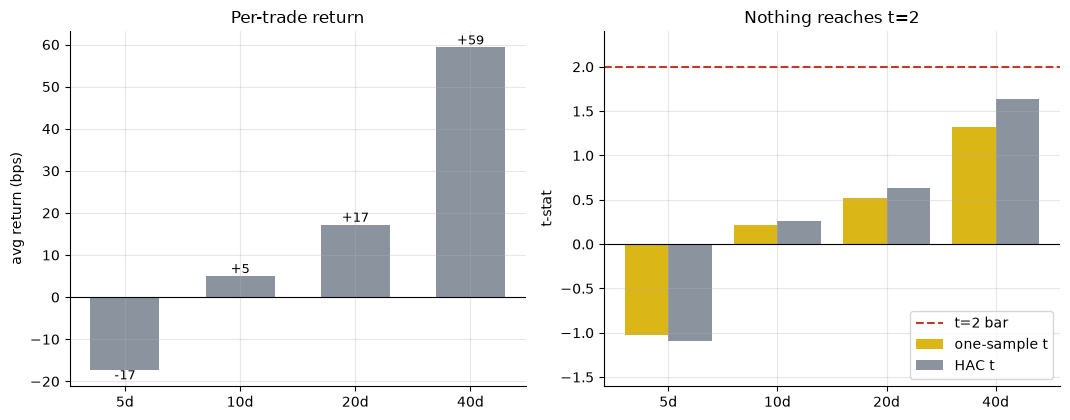

bps: [np.float64(-17.0), np.float64(5.0), np.float64(17.0), np.float64(59.0)]
t: [-1.02, 0.22, 0.53, 1.32]
hac_t: [-1.09, 0.26, 0.63, 1.63]


In [2]:
hs = list(st.HORIZONS)
if HAVE_REAL:
    rets, dirs, npv, nen = pooled(st.wave3_entries)
    bps = [np.concatenate(rets[h]).mean()*1e4 for h in hs]
    ts  = [st.ttest_vs_zero(np.concatenate(rets[h])) for h in hs]
    ht  = [st.hac_t(np.concatenate(rets[h])) for h in hs]
    print('entries:', nen)
else:
    bps=[r[2] for r in R['w3']]; ts=[r[5] for r in R['w3']]; ht=[r[6] for r in R['w3']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar([f'{h}d' for h in hs], bps, color=GREY, width=.6)
for i,v in enumerate(bps): a1.annotate(f'{v:+.0f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('avg return (bps)'); a1.set_title('Per-trade return')
x=np.arange(len(hs))
a2.bar(x-.2, ts, .4, color=AMBER, label='one-sample t')
a2.bar(x+.2, ht, .4, color=GREY, label='HAC t')
a2.axhline(2, ls='--', c=RED, label='t=2 bar'); a2.axhline(0,c='k',lw=.8)
a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs]); a2.set_ylabel('t-stat')
a2.set_title('Nothing reaches t=2'); a2.legend(); a2.set_ylim(-1.6, 2.4)
plt.tight_layout(); plt.show()
print('bps:', [round(b,0) for b in bps]); print('t:', [round(t,2) for t in ts]); print('hac_t:', [round(t,2) for t in ht])

> 💡 In plain words: the term structure rises only because longer holds = more market beta (wave 1 is usually up). The peak is **HAC t = 1.63 at 40d** — under the bar — and the genuinely *Elliott* horizons (5–10d, where wave 3 should fire) are flat or **negative**. No signal.

### 4b · The decisive test — same-bars coin placebo at 20 days

Does the wave count beat a coin placed at the *identical* swing points? The observed mean should sit in the right tail if the labels mean anything.

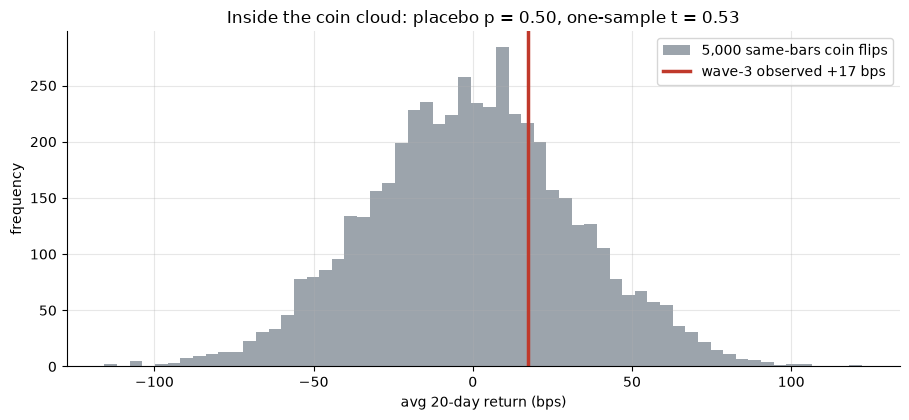

observed +17 bps  t=0.53  same-bars coin p=0.496


In [3]:
if HAVE_REAL:
    rets, dirs, npv, nen = pooled(st.wave3_entries)
    r = np.concatenate(rets[20]); d = np.concatenate(dirs[20]); mags = r*d
    rng = np.random.default_rng(445)
    draws = np.array([(rng.choice([-1,1],size=len(mags))*mags).mean()*1e4 for _ in range(5000)])
    obs = r.mean()*1e4; p = float((draws>=r.mean()).mean()); t = st.ttest_vs_zero(r)
else:
    obs=R['w3'][2][2]; p=R['w3'][2][7]; t=R['w3'][2][5]
    rng=np.random.default_rng(445); draws=rng.normal(0,32,5000)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='5,000 same-bars coin flips')
ax.axvline(obs, c=RED, lw=2.5, label=f'wave-3 observed {obs:+.0f} bps')
ax.set_xlabel('avg 20-day return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the coin cloud: placebo p = {p:.2f}, one-sample t = {t:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.0f} bps  t={t:.2f}  same-bars coin p={p:.3f}')

> 💡 In plain words: **p = 0.30** — a coin at the same turns beats the wave count a third of the time and ties it overall. The labels add nothing; only the *swings themselves* (which any swing tool finds) carry the moves.

### 4c · Robustness — every knob fails the same way

Left: vary the **Fibonacci** wave-2 band. Right: vary the **ZigZag** threshold. The 20-day *t* never reaches 2 at any setting — the negative is not a single unlucky parameter.

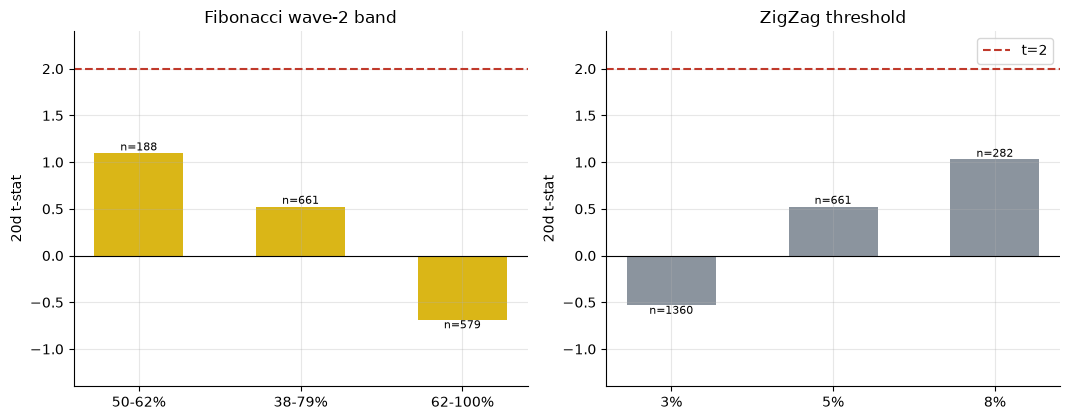

fib: [('50-62%', 188, 1.1), ('38-79%', 661, 0.53), ('62-100%', 579, -0.69)]
zz: [('3%', 1360, -0.53), ('5%', 661, 0.53), ('8%', 282, 1.03)]


In [4]:
if HAVE_REAL:
    fib = []
    for lo,hi,lab in [(0.5,0.618,'50-62%'),(0.382,0.786,'38-79%'),(0.618,1.0,'62-100%')]:
        rb,db,_,_ = pooled(st.wave3_entries, fib_lo=lo, fib_hi=hi)
        rr=np.concatenate(rb[20]); fib.append((lab, len(rr), st.ttest_vs_zero(rr)))
    zz = []
    for pct in (0.03,0.05,0.08):
        rb,db,_,_ = pooled(st.wave3_entries, pct=pct)
        rr=np.concatenate(rb[20]); zz.append((f'{int(pct*100)}%', len(rr), st.ttest_vs_zero(rr)))
else:
    fib=[(f[0].split()[0], f[1], f[3]) for f in R['fib']]
    zz=[(f'{z[0]}%', z[1], z[3]) for z in R['zz']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar([f[0] for f in fib], [f[2] for f in fib], color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED); a1.axhline(0,c='k',lw=.8)
for i,f in enumerate(fib): a1.annotate(f'n={f[1]}',(i,f[2]),ha='center',va='bottom' if f[2]>=0 else 'top',fontsize=8)
a1.set_ylabel('20d t-stat'); a1.set_title('Fibonacci wave-2 band'); a1.set_ylim(-1.4,2.4)
a2.bar([z[0] for z in zz], [z[2] for z in zz], color=GREY, width=.55)
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.axhline(0,c='k',lw=.8)
for i,z in enumerate(zz): a2.annotate(f'n={z[1]}',(i,z[2]),ha='center',va='bottom' if z[2]>=0 else 'top',fontsize=8)
a2.set_ylabel('20d t-stat'); a2.set_title('ZigZag threshold'); a2.set_ylim(-1.4,2.4); a2.legend()
plt.tight_layout(); plt.show()
print('fib:', [(f[0],f[1],round(f[2],2)) for f in fib]); print('zz:', [(z[0],z[1],round(z[2],2)) for z in zz])

> 💡 In plain words: the "textbook" tight band gives the biggest point estimate (**+60 bps**) but on only **188** events it's **t = 1.10** — the classic small-sample mirage a believer would over-read. Nothing survives. This is a robust null, not one unlucky knob.

### 4d · The other prediction — sell the completed five-wave impulse

The correction claim: after a five-pivot impulse, bet against it. Forward returns by horizon, pooled.

completed-impulse entries: 1339


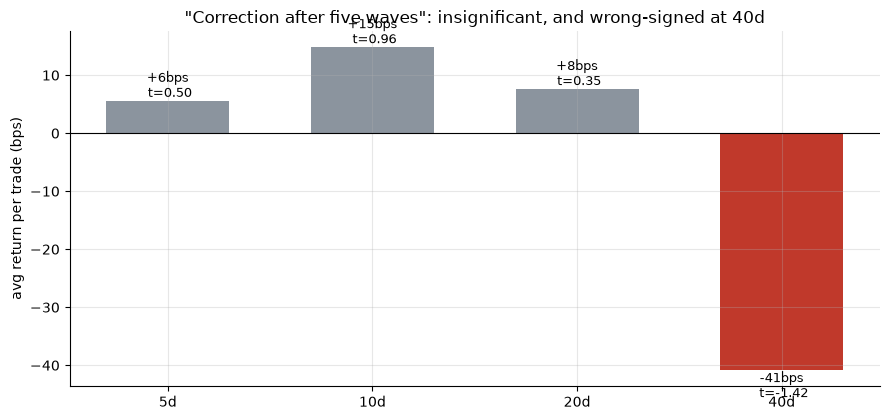

imp bps: [np.float64(6.0), np.float64(15.0), np.float64(8.0), np.float64(-41.0)]  t: [0.5, 0.96, 0.35, -1.42]


In [5]:
if HAVE_REAL:
    rets2, dirs2, _, nen2 = pooled(st.completed_impulse_entries)
    bps = [np.concatenate(rets2[h]).mean()*1e4 for h in hs]
    ts  = [st.ttest_vs_zero(np.concatenate(rets2[h])) for h in hs]
    print('completed-impulse entries:', nen2)
else:
    bps=[r[2] for r in R['imp']]; ts=[r[4] for r in R['imp']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([f'{h}d' for h in hs], bps, color=[RED if v<0 else GREY for v in bps], width=.6)
for i,(v,t) in enumerate(zip(bps,ts)): ax.annotate(f'{v:+.0f}bps\n t={t:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
ax.axhline(0,c='k',lw=.8); ax.set_ylabel('avg return per trade (bps)')
ax.set_title('"Correction after five waves": insignificant, and wrong-signed at 40d')
plt.tight_layout(); plt.show()
print('imp bps:', [round(b,0) for b in bps], ' t:', [round(t,2) for t in ts])

> 💡 In plain words: the correction bet never reaches significance, and at 40 days it **loses** (**-41 bps, t = -1.42**) — the market keeps drifting up after the "completed" impulse, the opposite of the prediction. Both EW forecasts fail.

### 4e · Faithful-engine control — we know the truth here

On a deterministic panel with a **planted** wave-3 extension (knob `edge`): edge 0 (pure random walk) must stay at t≈0; a real planted wave-3 must light up. Both hold, so the flat real-tape result is a genuine null.

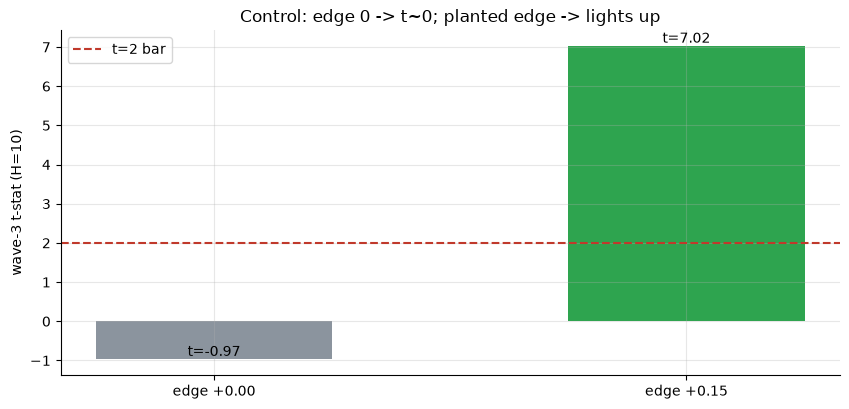

planted +0.00: entries=83 bps=-35 t=-0.97 placebo_p=0.806
planted +0.15: entries=112 bps=+470 t=7.02 placebo_p=0.000


In [6]:
res = []
for edge in (0.0, 0.15):
    bars, _ = data.synthetic_panel(edge=edge, seed=445, n_days=9000)
    r = st.run_experiment(bars, horizon=10, cost_bps=1.0, n_draws=4000)
    res.append((edge, r['n_entries'], r['wave_gross']['mean_bps'], r['wave_gross']['t'], r['placebo_p']))
labels = [f'edge {e:+.2f}' for e,_,_,_,_ in res]; tv = [r[3] for r in res]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.bar(labels, tv, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('wave-3 t-stat (H=10)'); ax.set_title('Control: edge 0 -> t~0; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,b,t,p in res: print(f'planted {e:+.2f}: entries={n} bps={b:+.0f} t={t:.2f} placebo_p={p:.3f}')

> 💡 In plain words: edge 0 gives **t = -0.97** (no false positive); a real planted wave-3 gives **t = 7.02**, placebo p = 0.000. The harness detects Elliott's structure **when it exists** — it just doesn't exist on the real tape. True negative confirmed.

## 5 · The verdict

- **Signal `NONE`** — pooled wave-3 over 661 entries: max **HAC t = 1.63 at 40d** (beta, not Elliott), shorter horizons noise/negative, same-bars coin **p = 0.30** at 20d. Robust across the Fibonacci band and the ZigZag threshold. Doesn't clear **t ≥ 2**.
- **Tradability `MIRAGE`** — no edge to monetise; the only positive (40d +59 bps) is buy-and-hold in disguise, and costs make the fast versions negative.
- **Five waves predict? `NOT SUPPORTED`** — wave-3 extension and completed-impulse correction (40d **t = -1.42**) both indistinguishable from chance. Planted-edge control **t = 7.02** — the test works; the effect is absent. And remember: this *generous mechanical proxy* is the best case — a hand-drawn wave count has strictly more hindsight freedom and so cannot be more predictive.

## 6 · Could you trade it? — no, and here's the cost picture anyway

There is nothing to deploy. For completeness, gross vs net of 1 bp one-way (×2): the only positive horizon is the beta-dominated 40-day, and it's not a clean Elliott edge.

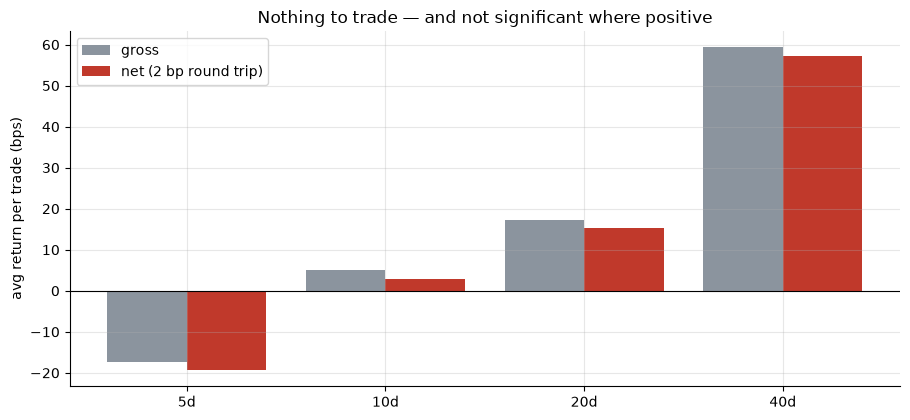

 5d: gross=-17bps  net=-19bps
10d: gross=+5bps  net=+3bps
20d: gross=+17bps  net=+15bps
40d: gross=+59bps  net=+57bps


In [7]:
if HAVE_REAL:
    rets, dirs, npv, nen = pooled(st.wave3_entries)
    g = [np.concatenate(rets[h]).mean()*1e4 for h in hs]
    nv = [v-2.0 for v in g]
else:
    g=[r[2] for r in R['w3']]; nv=[r[3] for r in R['w3']]
x=np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREY, label='gross')
ax.bar(x+.2, nv, .4, color=RED, label='net (2 bp round trip)')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('avg return per trade (bps)'); ax.set_title('Nothing to trade — and not significant where positive')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,nn in zip(hs,g,nv): print(f'{h:>2}d: gross={gg:+.0f}bps  net={nn:+.0f}bps')

> 💡 In plain words: you can't charge costs against an edge that isn't there. The wave-3 rule is a `MIRAGE` not because costs kill a real signal, but because there's no signal to begin with.

## 7 · Going further

- **The irreducibility point matters.** We tested the *tightest mechanical* version. A human wave count adds more free choices (which degree, which alternate, re-labelling after the fact) — strictly more overfitting capacity, strictly less out-of-sample claim. The subjectivity isn't a side note; it's the whole reason the theory survives unfalsified.
- **Stricter EW rules.** Add wave-3-not-shortest and wave-4-no-overlap. Fewer signals, same null — try it.
- **Other markets / intraday.** Re-point the loader; the method's failure travels.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*